In [3]:
import pandas as pd

df = pd.read_csv("clean_with_returns.csv", index_col=0, parse_dates=True)
df.head()

,INR,Oil,INR_return,Oil_return
Date,,,,
2020-01-03,71.415001,68.599998,0.005491,0.035472
2020-01-06,71.731003,68.910004,0.004425,0.004519
2020-01-07,71.787003,68.269997,0.000781,-0.009288
2020-01-08,72.160004,65.440002,0.005196,-0.041453
2020-01-09,71.411903,65.370003,-0.010367,-0.001070


In [4]:
import yfinance as yf

# US Dollar Index - measures dollar strength globally
dxy = yf.download("DX-Y.NYB", start="2020-01-01", end="2026-07-23")
dxy.columns = dxy.columns.get_level_values(0)
dxy.to_csv("raw_dxy.csv")
print("DXY data saved:", dxy.shape)

# Nifty 50 - proxy for FII sentiment toward India
nifty = yf.download("^NSEI", start="2020-01-01", end="2026-07-23")
nifty.columns = nifty.columns.get_level_values(0)
nifty.to_csv("raw_nifty.csv")
print("Nifty data saved:", nifty.shape)

[*********************100%***********************]  1 of 1 completed


DXY data saved: (1648, 5)


[*********************100%***********************]  1 of 1 completed

Nifty data saved: (1621, 5)


In [5]:
inr = pd.read_csv("raw_inr.csv", index_col=0, parse_dates=True)[["Close"]].rename(columns={"Close": "INR"})
oil = pd.read_csv("raw_oil.csv", index_col=0, parse_dates=True)[["Close"]].rename(columns={"Close": "Oil"})
dxy = pd.read_csv("raw_dxy.csv", index_col=0, parse_dates=True)[["Close"]].rename(columns={"Close": "DXY"})
nifty = pd.read_csv("raw_nifty.csv", index_col=0, parse_dates=True)[["Close"]].rename(columns={"Close": "Nifty"})

# Merge all four on matching dates only (inner join across all)
full = inr.join([oil, dxy, nifty], how="inner")

print("Full merged shape:", full.shape)
full.head()

Full merged shape: (1567, 4)


,INR,Oil,DXY,Nifty
Date,,,,
2020-01-02,71.025002,66.250000,96.849998,12282.200195
2020-01-03,71.415001,68.599998,96.839996,12226.650391
2020-01-06,71.731003,68.910004,96.669998,11993.049805
2020-01-07,71.787003,68.269997,96.980003,12052.950195
2020-01-08,72.160004,65.440002,97.300003,12025.349609


In [6]:
from scipy.stats import pearsonr

# Daily % returns for all four
full["INR_return"] = full["INR"].pct_change()
full["Oil_return"] = full["Oil"].pct_change()
full["DXY_return"] = full["DXY"].pct_change()
full["Nifty_return"] = full["Nifty"].pct_change()

full = full.dropna()

print("Shape after returns:", full.shape)
print()

# Check correlation of each variable against INR_return
for col in ["Oil_return", "DXY_return", "Nifty_return"]:
    corr, p = pearsonr(full[col], full["INR_return"])
    print(f"{col:15} correlation: {corr:+.4f}   p-value: {p:.4f}")

full.to_csv("clean_multifactor.csv")

Shape after returns: (1566, 8)

Oil_return      correlation: +0.0998   p-value: 0.0001
DXY_return      correlation: +0.1070   p-value: 0.0000
Nifty_return    correlation: -0.1560   p-value: 0.0000


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = full[["Oil_return", "DXY_return", "Nifty_return"]]
y = full["INR_return"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef:+.4f}")
print(f"Intercept: {model.intercept_:.6f}")
print(f"R² score: {r2:.4f}")
print(f"MAE: {mae:.6f}")

Coefficients:
  Oil_return: +0.0131
  DXY_return: +0.0866
  Nifty_return: -0.0538
Intercept: 0.000226
R² score: -0.0119
MAE: 0.002347


In [8]:
# Time-aware split: train on first 80% of dates, test on last 20%
split_point = int(len(full) * 0.8)

train = full.iloc[:split_point]
test = full.iloc[split_point:]

X_train = train[["Oil_return", "DXY_return", "Nifty_return"]]
y_train = train["INR_return"]
X_test = test[["Oil_return", "DXY_return", "Nifty_return"]]
y_test = test["INR_return"]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Train size:", len(train), " Test size:", len(test))

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nCoefficients:")
for name, coef in zip(X_train.columns, model.coef_):
    print(f"  {name}: {coef:+.4f}")
print(f"Intercept: {model.intercept_:.6f}")
print(f"R² score: {r2:.4f}")
print(f"MAE: {mae:.6f}")

Train period: 2020-01-03 00:00:00 to 2025-03-24 00:00:00
Test period: 2025-03-25 00:00:00 to 2026-07-22 00:00:00
Train size: 1252  Test size: 314

Coefficients:
  Oil_return: +0.0150
  DXY_return: +0.0981
  Nifty_return: -0.0396
Intercept: 0.000168
R² score: 0.0109
MAE: 0.002993


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"Random Forest R²: {rf_r2:.4f}")
print(f"Random Forest MAE: {rf_mae:.6f}")
print(f"\n(Compare to Linear Regression R²: 0.0109)")

# Which features did the forest find most useful?
for name, importance in zip(X_train.columns, rf_model.feature_importances_):
    print(f"  {name}: {importance:.4f}")

Random Forest R²: 0.0045
Random Forest MAE: 0.002943

(Compare to Linear Regression R²: 0.0109)
  Oil_return: 0.3810
  DXY_return: 0.3023
  Nifty_return: 0.3167


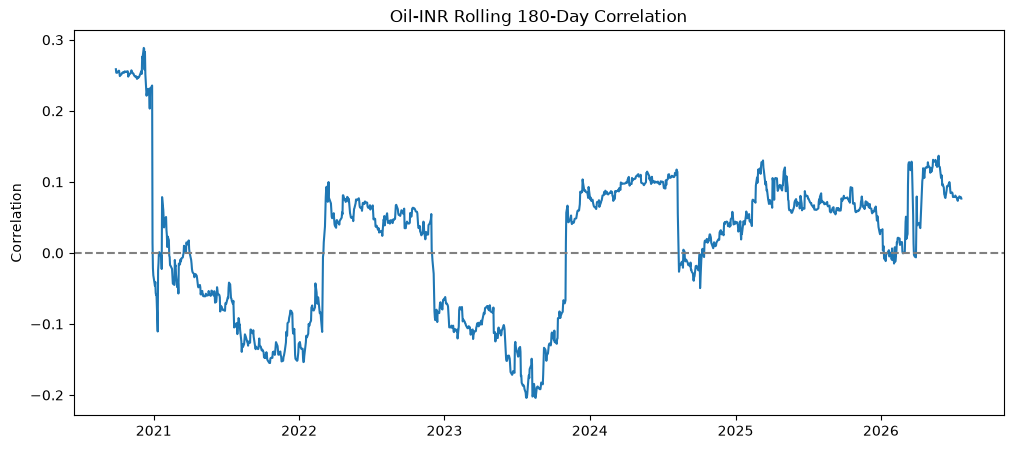

In [10]:
window = 180
full["Oil_INR_rolling_corr"] = full["Oil_return"].rolling(window).corr(full["INR_return"])

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(full.index, full["Oil_INR_rolling_corr"])
plt.axhline(0, color="gray", linestyle="--")
plt.title("Oil-INR Rolling 180-Day Correlation")
plt.ylabel("Correlation")
plt.show()

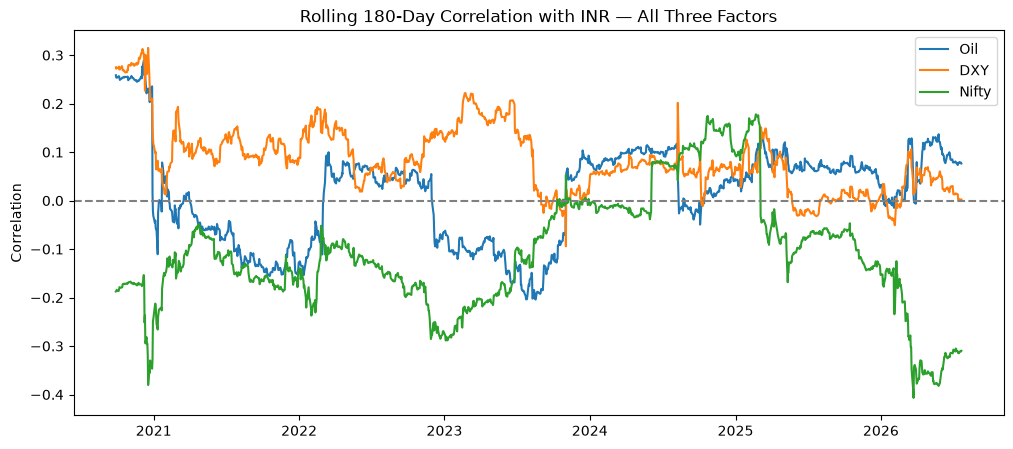

In [11]:
full["DXY_INR_rolling_corr"] = full["DXY_return"].rolling(window).corr(full["INR_return"])
full["Nifty_INR_rolling_corr"] = full["Nifty_return"].rolling(window).corr(full["INR_return"])

plt.figure(figsize=(12,5))
plt.plot(full.index, full["Oil_INR_rolling_corr"], label="Oil")
plt.plot(full.index, full["DXY_INR_rolling_corr"], label="DXY")
plt.plot(full.index, full["Nifty_INR_rolling_corr"], label="Nifty")
plt.axhline(0, color="gray", linestyle="--")
plt.legend()
plt.title("Rolling 180-Day Correlation with INR — All Three Factors")
plt.ylabel("Correlation")
plt.show()

In [12]:
# Last retrained: 2026-07-29
# Re-run this cell periodically (recommended: every 3-6 months) with updated end date

def retrain_model():
    import datetime
    today = datetime.date.today().strftime("%Y-%m-%d")
    # ... fetch/clean/merge/split/fit exactly as done above, using end=today
    # ... save with joblib.dump(new_model, "rupee_model.pkl")
    pass

In [13]:
# Using your existing daily 'full' dataframe
oil_inr = full[["Oil", "INR"]]

weekly = oil_inr.resample("W").last()
monthly = oil_inr.resample("ME").last()
yearly = oil_inr.resample("YE").last()

weekly["Oil_return"] = weekly["Oil"].pct_change()
weekly["INR_return"] = weekly["INR"].pct_change()
monthly["Oil_return"] = monthly["Oil"].pct_change()
monthly["INR_return"] = monthly["INR"].pct_change()
yearly["Oil_return"] = yearly["Oil"].pct_change()
yearly["INR_return"] = yearly["INR"].pct_change()

weekly = weekly.dropna()
monthly = monthly.dropna()
yearly = yearly.dropna()

print("Weekly rows:", len(weekly))
print("Monthly rows:", len(monthly))
print("Yearly rows:", len(yearly))

Weekly rows: 342
Monthly rows: 78
Yearly rows: 6


In [14]:
from scipy.stats import pearsonr

for name, df in [("Daily", full), ("Weekly", weekly), ("Monthly", monthly), ("Yearly", yearly)]:
    if len(df) > 3:
        corr, p = pearsonr(df["Oil_return"], df["INR_return"])
        print(f"{name:8} correlation: {corr:+.4f}   p-value: {p:.4f}   (n={len(df)})")

Daily    correlation: +0.0998   p-value: 0.0001   (n=1566)
Weekly   correlation: +0.1194   p-value: 0.0273   (n=342)
Monthly  correlation: +0.0470   p-value: 0.6829   (n=78)
Yearly   correlation: +0.1785   p-value: 0.7350   (n=6)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Time-based split, same logic as your daily model
split_point = int(len(weekly) * 0.8)

train_w = weekly.iloc[:split_point]
test_w = weekly.iloc[split_point:]

X_train_w = train_w[["Oil_return"]]
y_train_w = train_w["INR_return"]
X_test_w = test_w[["Oil_return"]]
y_test_w = test_w["INR_return"]

print("Weekly train period:", train_w.index.min(), "to", train_w.index.max())
print("Weekly test period:", test_w.index.min(), "to", test_w.index.max())
print("Train size:", len(train_w), " Test size:", len(test_w))

weekly_model = LinearRegression()
weekly_model.fit(X_train_w, y_train_w)
y_pred_w = weekly_model.predict(X_test_w)

r2_w = r2_score(y_test_w, y_pred_w)
mae_w = mean_absolute_error(y_test_w, y_pred_w)

print(f"\nWeekly Oil coefficient: {weekly_model.coef_[0]:+.4f}")
print(f"Intercept: {weekly_model.intercept_:.6f}")
print(f"R² score: {r2_w:.4f}")
print(f"MAE: {mae_w:.6f}")
print(f"\n(Compare to Daily R²: 0.0109 [multi-factor] / 0.0096 [oil-only])")

Weekly train period: 2020-01-12 00:00:00 to 2025-03-30 00:00:00
Weekly test period: 2025-04-06 00:00:00 to 2026-07-26 00:00:00
Train size: 273  Test size: 69

Weekly Oil coefficient: +0.0019
Intercept: 0.000685
R² score: -0.0047
MAE: 0.005590

(Compare to Daily R²: 0.0109 [multi-factor] / 0.0096 [oil-only])


In [16]:
# Measure oil's rolling volatility (20-day standard deviation of returns)
full["Oil_volatility"] = full["Oil_return"].rolling(20).std()

# Define "high volatility" as the top 25% most volatile days
volatility_threshold = full["Oil_volatility"].quantile(0.75)
full["Regime"] = full["Oil_volatility"].apply(
    lambda x: "High Volatility" if x > volatility_threshold else "Normal"
)

full_clean = full.dropna(subset=["Oil_volatility"])

print("Volatility threshold (75th percentile):", volatility_threshold)
print(full_clean["Regime"].value_counts())

Volatility threshold (75th percentile): 0.026547747135165514
Regime
Normal             1160
High Volatility     387
Name: count, dtype: int64


In [17]:
from scipy.stats import pearsonr

for regime in ["Normal", "High Volatility"]:
    subset = full_clean[full_clean["Regime"] == regime]
    corr, p = pearsonr(subset["Oil_return"], subset["INR_return"])
    print(f"{regime:16} correlation: {corr:+.4f}   p-value: {p:.4f}   (n={len(subset)})")

Normal           correlation: -0.0235   p-value: 0.4230   (n=1160)
High Volatility  correlation: +0.1847   p-value: 0.0003   (n=387)


In [18]:
# For each year, compute correlation using ONLY high-volatility days that year
full_clean["Year"] = full_clean.index.year

print("Correlation among High-Volatility days, by year:\n")
for year in sorted(full_clean["Year"].unique()):
    year_data = full_clean[(full_clean["Year"] == year) & (full_clean["Regime"] == "High Volatility")]
    if len(year_data) > 5:  # need at least a few points to bother testing
        corr, p = pearsonr(year_data["Oil_return"], year_data["INR_return"])
        print(f"{year}   correlation: {corr:+.4f}   p-value: {p:.4f}   (n={len(year_data)})")
    else:
        print(f"{year}   too few high-volatility days (n={len(year_data)}) to test")

Correlation among High-Volatility days, by year:

2020   correlation: +0.2844   p-value: 0.0052   (n=95)
2021   correlation: +0.0227   p-value: 0.8708   (n=54)
2022   correlation: +0.0850   p-value: 0.3601   (n=118)
2023   correlation: +0.0154   p-value: 0.9582   (n=14)
2024   too few high-volatility days (n=3) to test
2025   correlation: +0.0404   p-value: 0.8585   (n=22)
2026   correlation: +0.0950   p-value: 0.3991   (n=81)
